#  Week 2: Advanced Feature Engineering

##  Objective
Transform raw time-series data into meaningful features for machine learning models.

##  Why This Step is Important
Models cannot understand dates directly.
We convert time into patterns like:
- Seasonality
- Trends
- Past behavior (lags)

---

In [1]:
# ── CELL 1: Import and Load ──────────────────────────────────

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings

warnings.filterwarnings('ignore')
sns.set_theme(style="whitegrid")

# Load dataset
train = pd.read_csv('../data/train.csv', parse_dates=['date'])

print(" Data loaded successfully!")
print("Shape:", train.shape)

train.head()

 Data loaded successfully!
Shape: (913000, 4)


,date,store,item,sales
0,2013-01-01,1,1,13
1,2013-01-02,1,1,11
2,2013-01-03,1,1,14
3,2013-01-04,1,1,13
4,2013-01-05,1,1,10


## Step 2: Focus on a Single Store-Item Combination

To simplify modeling and capture clear patterns, we select:
- One store
- One item

### Why?
- Reduces noise
- Makes time-series modeling more accurate
- Helps understand demand behavior clearly

---

In [3]:
# ── CELL 2: Filter Single Store & Item ───────────────────────

STORE_ID = train['store'].mode()[0]   # Most frequent store
ITEM_ID  = train['item'].mode()[0]    # Most frequent item

store_df = train[
    (train['store'] == STORE_ID) &
    (train['item'] == ITEM_ID)
].copy()

# Sort by date
store_df = store_df.sort_values('date').reset_index(drop=True)

# Keep only required columns
store_df = store_df[['date', 'sales']].copy()

print(f"Store: {STORE_ID} | Item: {ITEM_ID}")
print(f"Records: {len(store_df)}")
print(f"Date range: {store_df['date'].min().date()} → {store_df['date'].max().date()}")

store_df.head()
top_combo = (
    train.groupby(['store', 'item'])['sales']
    .sum()
    .reset_index()
    .sort_values('sales', ascending=False)
    .iloc[0]
)

STORE_ID = top_combo['store']
ITEM_ID  = top_combo['item']

print(" Top selling combination:", STORE_ID, ITEM_ID)

Store: 1 | Item: 1
Records: 1826
Date range: 2013-01-01 → 2017-12-31
 Top selling combination: 2 28


##  Step 3: Calendar Feature Engineering

We extract time-based features from the `date` column to help models understand patterns.

###  Features Created:

#### Basic Time Features
- Day of week (0 = Monday, 6 = Sunday)
- Day of month
- Month
- Quarter
- Year
- Day of year
- Week of year

#### 🔹 Binary Flags
- Weekend indicator
- Month start / end
- Quarter start

### Why This Matters:
Machine learning models cannot interpret raw dates.
These features help capture:
- Weekly patterns (e.g., weekends vs weekdays)
- Monthly trends
- Seasonal behavior

---

In [4]:
# ── CELL 3: Calendar Features ───────────────────────────────

df = store_df.copy()

# Ensure datetime
df['date'] = pd.to_datetime(df['date'])

# ── Basic calendar features ─
df['day_of_week']  = df['date'].dt.dayofweek
df['day_of_month'] = df['date'].dt.day
df['month']        = df['date'].dt.month
df['quarter']      = df['date'].dt.quarter
df['year']         = df['date'].dt.year
df['day_of_year']  = df['date'].dt.dayofyear
df['week_of_year'] = df['date'].dt.isocalendar().week.astype(int)

# ── Binary features ─
df['is_weekend']       = df['day_of_week'].isin([5, 6]).astype(int)
df['is_month_start']   = df['date'].dt.is_month_start.astype(int)
df['is_month_end']     = df['date'].dt.is_month_end.astype(int)
df['is_quarter_start'] = df['date'].dt.is_quarter_start.astype(int)

print("✅ Calendar features added successfully!")
df.head()

✅ Calendar features added successfully!


,date,sales,day_of_week,day_of_month,month,quarter,year,day_of_year,week_of_year,is_weekend,is_month_start,is_month_end,is_quarter_start
0,2013-01-01,13,1,1,1,1,2013,1,1,0,1,0,1
1,2013-01-02,11,2,2,1,1,2013,2,1,0,0,0,0
2,2013-01-03,14,3,3,1,1,2013,3,1,0,0,0,0
3,2013-01-04,13,4,4,1,1,2013,4,1,0,0,0,0
4,2013-01-05,10,5,5,1,1,2013,5,1,1,0,0,0


### Cyclical Encoding (Advanced)

Time features like day of week are cyclical:
- Sunday is close to Monday
- December is close to January

We encode them using sine/cosine transformation.

In [5]:
# Cyclical encoding for day of week
df['dow_sin'] = np.sin(2 * np.pi * df['day_of_week'] / 7)
df['dow_cos'] = np.cos(2 * np.pi * df['day_of_week'] / 7)

# Cyclical encoding for month
df['month_sin'] = np.sin(2 * np.pi * df['month'] / 12)
df['month_cos'] = np.cos(2 * np.pi * df['month'] / 12)

print(" Cyclical features added!")

 Cyclical features added!


##  Step 4: Holiday & Event-Based Features (Simulated)

Since external holiday data is not available, we simulate demand-impacting events using date logic.

###  Features Created:
- Festival season indicator (high demand months)
- Month-end effect (salary period)
- Pre-weekend effect (Friday boost)

###  Why This Matters:
Customer demand often spikes during:
- Festivals
- Salary periods
- Weekends

These features help capture such behavior without external datasets.

In [6]:
# ── CELL 4: Simulated Holiday Features ───────────────────────

# Festival months (example: Nov, Dec)
df['is_festival_season'] = df['month'].isin([11, 12]).astype(int)

# Month-end effect (last 3 days of month)
df['is_month_end_peak'] = (df['day_of_month'] >= 28).astype(int)

# Pre-weekend effect (Friday boost)
df['is_friday'] = (df['day_of_week'] == 4).astype(int)

print("✅ Simulated holiday/event features added!")
df[['date','is_festival_season','is_month_end_peak','is_friday']].head()

# Identify high demand months from data
monthly_sales = df.groupby('month')['sales'].mean()

high_months = monthly_sales[monthly_sales > monthly_sales.mean()].index

df['is_high_demand_month'] = df['month'].isin(high_months).astype(int)

print("🔥 High demand months:", list(high_months))

✅ Simulated holiday/event features added!
🔥 High demand months: [4, 5, 6, 7, 8, 9, 11]


## Step 5: Trend & Demand-Based Features

Since external economic indicators (like oil price) are unavailable,
we create internal features that capture:

- Long-term growth trends
- Demand intensity
- Sales momentum

###  Why This Matters:
These features help the model understand:
- Whether demand is increasing
- How strong recent sales patterns are

In [8]:
# ── CELL 5: Trend & Demand Features ─────────────────────────

# Trend (time progression)
df['trend'] = np.arange(len(df))

# Sales momentum (difference from previous day)
df['sales_diff'] = df['sales'].diff()

# Percentage change
df['sales_pct_change'] = df['sales'].pct_change()

print("✅ Trend and demand features created!")
df[['date','sales','trend','sales_diff']].head()

✅ Trend and demand features created!


,date,sales,trend,sales_diff
0,2013-01-01,13,0,NaN
1,2013-01-02,11,1,-2.0
2,2013-01-03,14,2,3.0
3,2013-01-04,13,3,-1.0
4,2013-01-05,10,4,-3.0


##  Step 6: Lag Feature Engineering

Lag features capture past sales behavior.

###  What are Lag Features?
They represent:
> "What were sales N days ago?"

###  Lags Used:
- 1 day ago → short-term memory
- 7 days ago → weekly pattern
- 14 days ago → bi-weekly pattern
- 21 days ago
- 28 days ago → monthly cycle

###  Why This is Important:
Time-series models rely heavily on past values.
Lag features allow machine learning models to:
- Learn trends
- Capture seasonality
- Predict future demand accurately

---

In [9]:
# ── CELL 6: Lag Features ─────────────────────────────────────

LAG_DAYS = [1, 7, 14, 21, 28]

for lag in LAG_DAYS:
    df[f'lag_{lag}'] = df['sales'].shift(lag)

print("✅ Lag features created:")
print([f'lag_{l}' for l in LAG_DAYS])

✅ Lag features created:
['lag_1', 'lag_7', 'lag_14', 'lag_21', 'lag_28']


###  Advanced: Lag Difference Features

We calculate how much sales changed compared to past values.

This captures demand acceleration or decline.

In [10]:
for lag in [7, 14]:
    df[f'lag_diff_{lag}'] = df['sales'] - df[f'lag_{lag}']

print(" Lag difference features added!")

 Lag difference features added!


###  Lag Ratio Features

We compare current sales to past sales.

This helps detect growth patterns.

In [12]:
for lag in [7, 14]:
    df[f'lag_ratio_{lag}'] = df['sales'] / (df[f'lag_{lag}'] + 1)

print(" Lag ratio features added!")

 Lag ratio features added!


## Step 7: Rolling Window Statistics

Rolling features capture recent trends and variability in sales.

###  What are Rolling Features?
They compute statistics over a moving window of past values.

###  Windows Used:
- 7 days → weekly trend
- 14 days → short-term trend
- 28 days → monthly trend

###  Features Created:
- Rolling Mean → average demand
- Rolling Std → demand volatility
- Rolling Max → peak demand
- Rolling Min → lowest demand

###  Important:
We use `.shift(1)` to ensure:
> Only past data is used (no future leakage)

###  Why This Matters:
These features help the model understand:
- Demand stability
- Recent trends
- Sudden spikes or drops

---

In [13]:
# ── CELL 7: Rolling Window Statistics ────────────────────────

WINDOWS = [7, 14, 28]

for w in WINDOWS:
    df[f'rolling_mean_{w}'] = df['sales'].shift(1).rolling(window=w).mean()
    df[f'rolling_std_{w}']  = df['sales'].shift(1).rolling(window=w).std()
    df[f'rolling_max_{w}']  = df['sales'].shift(1).rolling(window=w).max()
    df[f'rolling_min_{w}']  = df['sales'].shift(1).rolling(window=w).min()

print("✅ Rolling window features created:")
print([f'rolling_mean_{w}' for w in WINDOWS])

✅ Rolling window features created:
['rolling_mean_7', 'rolling_mean_14', 'rolling_mean_28']


###  Exponential Moving Average (EMA)

EMA gives more weight to recent data, making it more responsive to changes.

In [15]:
for span in [7, 14]:
    df[f'ema_{span}'] = df['sales'].shift(1).ewm(span=span, adjust=False).mean()

print(" EMA features added!")

 EMA features added!


### Rolling Trend Feature

We estimate short-term trend direction using rolling mean differences.

In [16]:
df['rolling_trend_7'] = df['rolling_mean_7'] - df['rolling_mean_14']

print(" Rolling trend feature added!")

 Rolling trend feature added!


##  Handling Missing Values from Rolling Features

Rolling calculations introduce missing values at the beginning.

We remove them to ensure clean model input.

In [17]:
df = df.dropna().reset_index(drop=True)

print("✅ Dataset cleaned after rolling features")
print("Final shape:", df.shape)

✅ Dataset cleaned after rolling features
Final shape: (1798, 48)


##  Step 8: Exponential Moving Average (EMA)

EMA is a type of moving average that gives **more importance to recent data points**.

###  Difference from Rolling Mean:
- Rolling Mean → treats all past values equally
- EMA → prioritizes recent sales

###  Spans Used:
- 7 days → short-term trend
- 14 days → medium-term trend

### Why This Matters:
Demand in real-world scenarios changes quickly.
EMA helps the model:
- React faster to recent changes
- Capture momentum more effectively

###  Important:
We use `.shift(1)` to avoid data leakage.

In [18]:
# ── CELL 8: Exponential Moving Average ──────────────────────

for span in [7, 14]:
    df[f'ewm_{span}'] = df['sales'].shift(1).ewm(span=span, adjust=False).mean()

print("✅ Exponential moving averages added!")

✅ Exponential moving averages added!


###  EMA Difference (Momentum Feature)

We compare short-term EMA vs long-term EMA to detect trend direction.

In [19]:
df['ema_diff'] = df['ewm_7'] - df['ewm_14']

print(" EMA difference feature added!")

 EMA difference feature added!


##  Step 9: Handle Missing Values

Lag, rolling, and EMA features introduce missing values at the beginning of the dataset.

###  Why does this happen?
- Lag features need past values → first few rows don’t have history
- Rolling windows need enough data points
- EMA also depends on previous values

###  Solution:
We remove these rows to ensure:
- Clean training data
- No invalid values
- Better model performance

---

In [21]:
# ── CELL 9: Drop NaN rows created by lag/rolling features ────

print(f"Rows before drop: {len(df)}")

df = df.dropna().reset_index(drop=True)

print(f"Rows after drop:  {len(df)}")
print(f"Features created: {df.shape[1]} columns")

Rows before drop: 1798
Rows after drop:  1797
Features created: 51 columns


In [22]:
nan_counts = df.isnull().sum()
print("Missing values per column:\n", nan_counts[nan_counts > 0])

Missing values per column:
 Series([], dtype: int64)


##  Step 10: Time-Series Train-Test Split

We split the dataset based on time instead of randomly.

### Why Not Random Split?
In time-series problems:
- Future data must NOT be used to predict the past
- Random split causes data leakage

###  Our Approach:
- Train → Historical data
- Test → Future unseen data

###  Split Date:
We use a cutoff date to simulate real-world forecasting.

---

In [24]:
# ── CELL 10: Train/Test Split (Time-Based!) ──────────────────

SPLIT_DATE = '2017-07-01'

train_df = df[df['date'] < SPLIT_DATE].copy()
test_df  = df[df['date'] >= SPLIT_DATE].copy()

print(f"Train: {train_df['date'].min().date()} → {train_df['date'].max().date()} | rows: {len(train_df)}")
print(f"Test:  {test_df['date'].min().date()}  → {test_df['date'].max().date()}  | rows: {len(test_df)}")

Train: 2013-01-30 → 2017-06-30 | rows: 1613
Test:  2017-07-01  → 2017-12-31  | rows: 184


##  Step 11: Save Feature-Engineered Dataset

We save the final processed dataset for:
- Model training (Week 3)
- Reproducibility
- Version control

###  Why Save This?
- Avoid recomputing features every time
- Separate data processing from modeling
- Follow good MLOps practice

###  Output:
Saved as: `engineered_features.csv`

---

In [25]:
# ── CELL 11: Save Engineered Dataset ────────────────────────

import os

output_path = '../outputs'

# Ensure folder exists
if not os.path.exists(output_path):
    os.makedirs(output_path)

# Save file
df.to_csv(f'{output_path}/engineered_features.csv', index=False)

print("✅ Feature-engineered dataset saved!")

print(f"\nFinal feature list ({df.shape[1]} columns):")
print(list(df.columns))

✅ Feature-engineered dataset saved!

Final feature list (51 columns):
['date', 'sales', 'day_of_week', 'day_of_month', 'month', 'quarter', 'year', 'day_of_year', 'week_of_year', 'is_weekend', 'is_month_start', 'is_month_end', 'is_quarter_start', 'dow_sin', 'dow_cos', 'month_sin', 'month_cos', 'is_festival_season', 'is_month_end_peak', 'is_friday', 'is_high_demand_month', 'trend', 'sales_diff', 'sales_pct_change', 'lag_1', 'lag_7', 'lag_14', 'lag_21', 'lag_28', 'lag_diff_7', 'lag_diff_14', 'lag_ratio_7', 'lag_ratio_14', 'rolling_mean_7', 'rolling_std_7', 'rolling_max_7', 'rolling_min_7', 'rolling_mean_14', 'rolling_std_14', 'rolling_max_14', 'rolling_min_14', 'rolling_mean_28', 'rolling_std_28', 'rolling_max_28', 'rolling_min_28', 'ema_7', 'ema_14', 'rolling_trend_7', 'ewm_7', 'ewm_14', 'ema_diff']


In [26]:
train_df.to_csv(f'{output_path}/train_final.csv', index=False)
test_df.to_csv(f'{output_path}/test_final.csv', index=False)

print("Train & Test datasets saved separately!")

Train & Test datasets saved separately!


## Step 12: Feature Correlation Analysis

We analyze how each feature is related to the target variable (`sales`).

###  Objective:
- Identify most important features
- Remove weak or redundant features (if needed)
- Understand relationships before modeling

###  What This Shows:
- Positive correlation → feature increases sales
- Negative correlation → feature decreases sales
- Near zero → weak relationship

###  Why This Matters:
Helps improve:
- Model performance
- Feature selection
- Interpretability

---

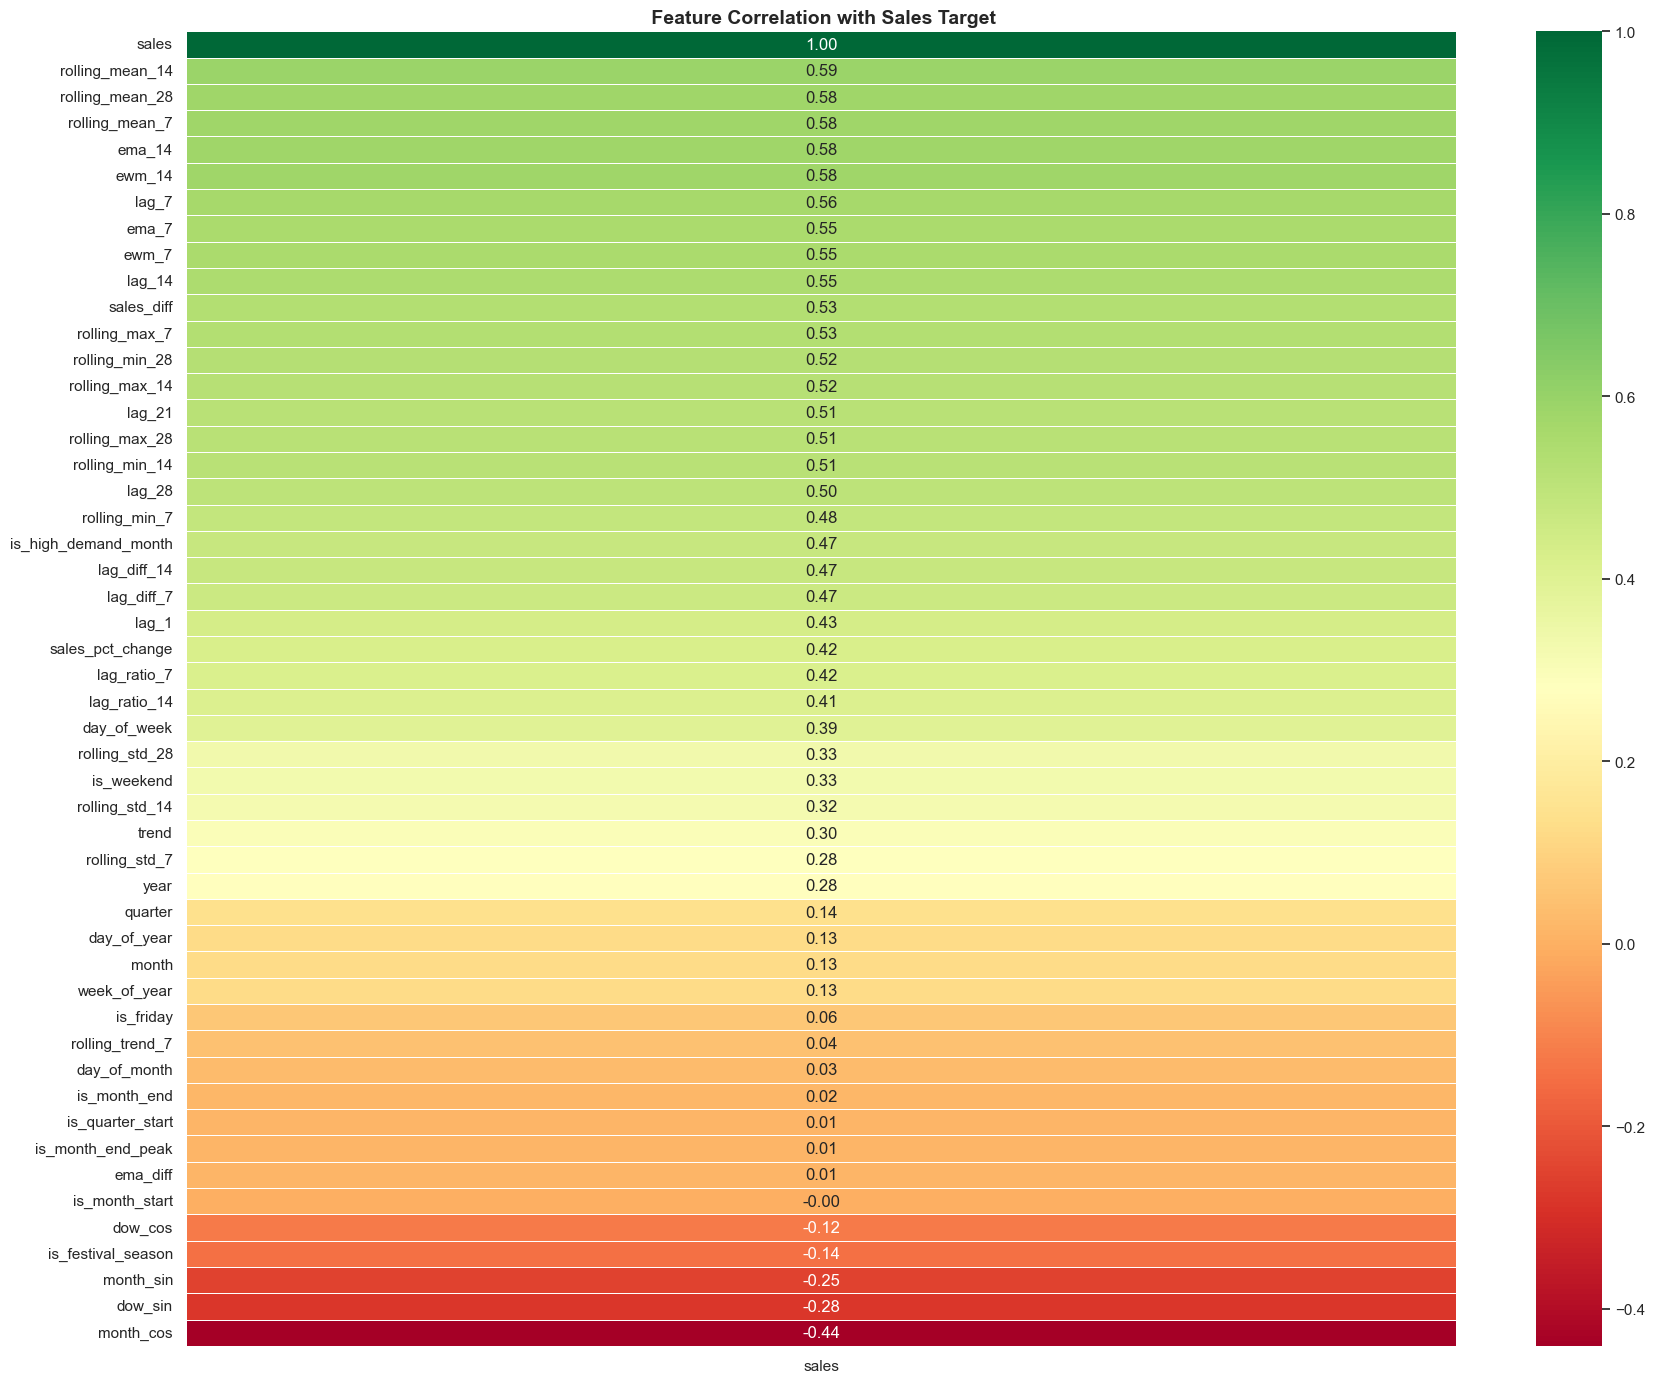

In [27]:
# ── CELL 12: Correlation Heatmap of Features ────────────────

feature_cols = [c for c in df.columns if c not in ['date', 'sales']]

corr = df[feature_cols + ['sales']].corr()

plt.figure(figsize=(18, 14))

sns.heatmap(
    corr[['sales']].sort_values('sales', ascending=False),
    annot=True,
    fmt='.2f',
    cmap='RdYlGn',
    linewidths=0.5,
    linecolor='white',
    cbar=True
)

plt.title(' Feature Correlation with Sales Target',
          fontsize=14, fontweight='bold')

plt.tight_layout()
plt.savefig('../outputs/plot6_correlation_heatmap.png', dpi=150)

plt.show()

###  Top Correlated Features

We extract features most strongly related to sales.

In [28]:
top_corr = corr['sales'].abs().sort_values(ascending=False)

print("Top 10 Important Features:")
print(top_corr.head(10))

Top 10 Important Features:
sales              1.000000
rolling_mean_14    0.592288
rolling_mean_28    0.583410
rolling_mean_7     0.582977
ema_14             0.579164
ewm_14             0.578493
lag_7              0.561704
ema_7              0.554900
ewm_7              0.554746
lag_14             0.545961
Name: sales, dtype: float64


In [29]:
low_corr = top_corr[top_corr < 0.05].index
print(" Weak features:", list(low_corr))

 Weak features: ['rolling_trend_7', 'day_of_month', 'is_month_end', 'is_quarter_start', 'is_month_end_peak', 'ema_diff', 'is_month_start']
